# Importing necessary libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Read the dataset in csv format

In [3]:
data = pd.read_csv("../data/xy_data.csv")

# Info about the dataset(basic)

In [4]:
print("Dataset Shape:")
print(data.shape)

print("\nColumn Names:")
print(data.columns)

print("\nMissing Values:")
print(data.isnull().sum())

Dataset Shape:
(1500, 2)

Column Names:
Index(['x', 'y'], dtype='object')

Missing Values:
x    0
y    0
dtype: int64


# Print statistical summary

In [5]:
print(data.describe())

                 x            y
count  1500.000000  1500.000000
mean     83.713931    58.263519
std      13.697157     7.696524
min      59.657204    46.032295
25%      72.282910    51.124211
50%      84.710995    57.681288
75%      93.368257    66.138374
max     109.231520    69.685510


# Separate x and y

In [6]:
x = data["x"].values
y = data["y"].values

# Plot the x,y Points

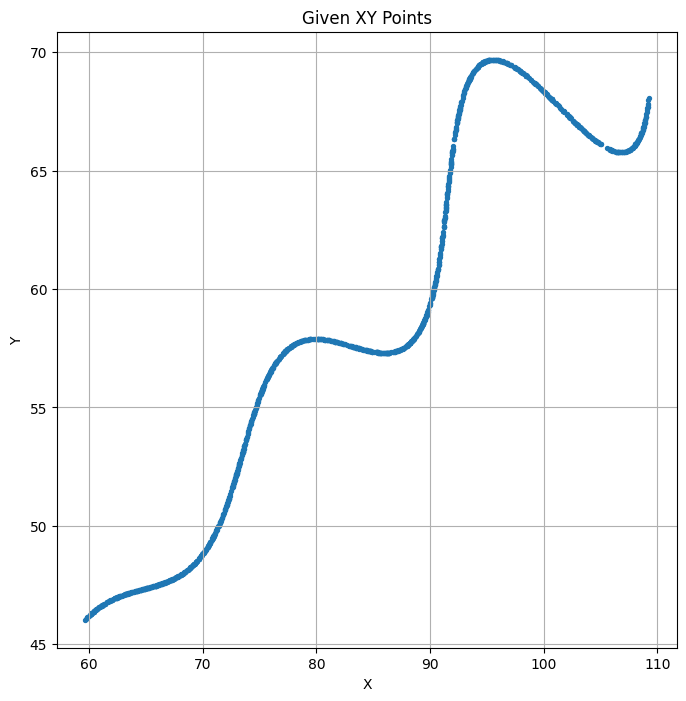

In [7]:
plt.figure(figsize=(8, 8))

plt.scatter(x, y, s=8)

plt.title("Given XY Points")
plt.xlabel("X")
plt.ylabel("Y")

plt.grid(True)

plt.show()

# Checking Point Ordering

In [8]:
print("First 10 x values")
print(x[:10])

print()

print("First 10 y values")
print(y[:10])

First 10 x values
[ 88.364456  74.283936  60.256474  82.13437  101.03639   69.284134
  77.81013   91.29688  107.66841   76.40689 ]

First 10 y values
[57.784378 54.40678  46.311462 57.717567 67.84934  48.406086 57.588833
 63.03135  65.91405  56.871525]


# Checking the Data Types

In [9]:
print(data.dtypes)

x    float64
y    float64
dtype: object


# Checking the Range of x and y to get an idea of the scale of the curve.

In [10]:
print("X Range")
print("Minimum :", np.min(x))
print("Maximum :", np.max(x))

print()

print("Y Range")
print("Minimum :", np.min(y))
print("Maximum :", np.max(y))

X Range
Minimum : 59.657204
Maximum : 109.23152

Y Range
Minimum : 46.032295
Maximum : 69.68551


# plot with lines
If the graph looks like one continuous curve, then the points are already ordered.

If it looks like spaghetti (lines jumping everywhere), then the points are shuffled.

This is a very important observation before optimization.

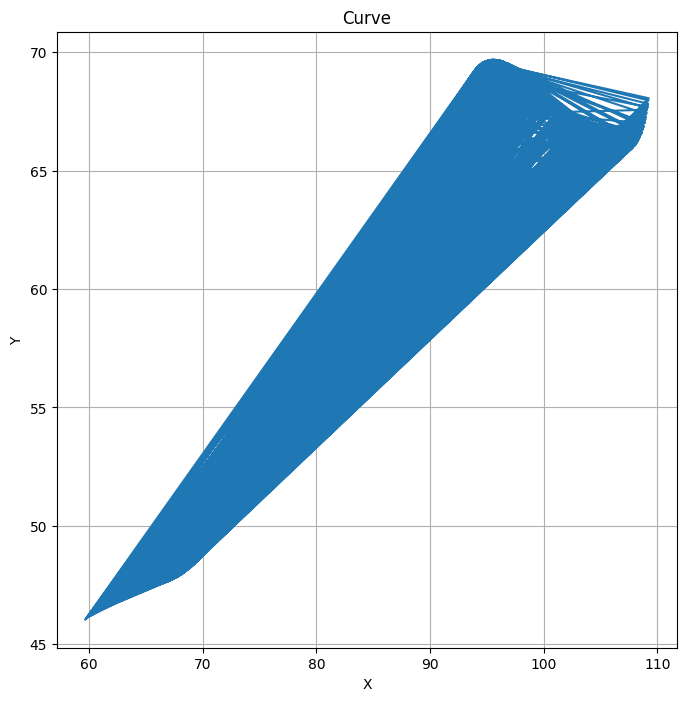

In [11]:
plt.figure(figsize=(8,8))

plt.plot(x, y)

plt.title("Curve")
plt.xlabel("X")
plt.ylabel("Y")

plt.grid(True)

plt.show()

# Number the Points

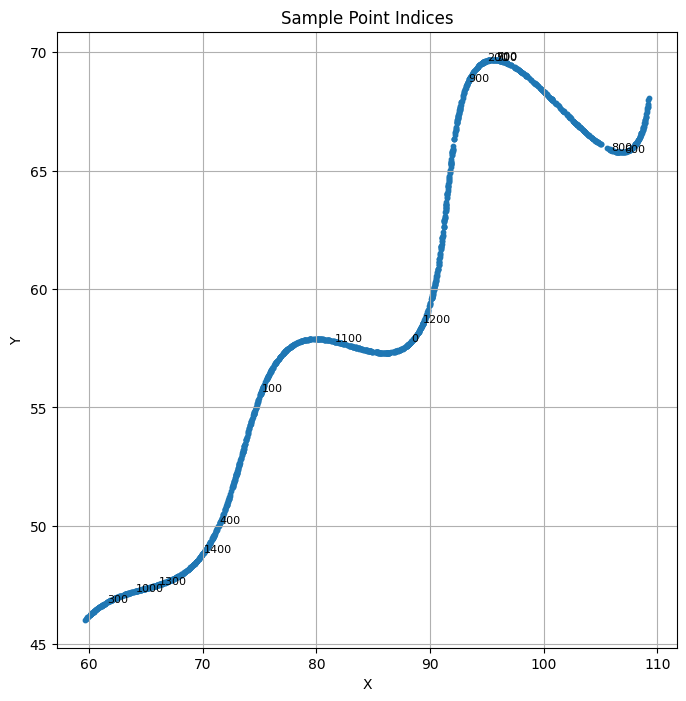

In [12]:
plt.figure(figsize=(8,8))

plt.scatter(x, y, s=10)

for i in range(0, len(x), 100):
    plt.text(x[i], y[i], str(i), fontsize=8)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Sample Point Indices")

plt.grid(True)

plt.show()

# Save the Plot

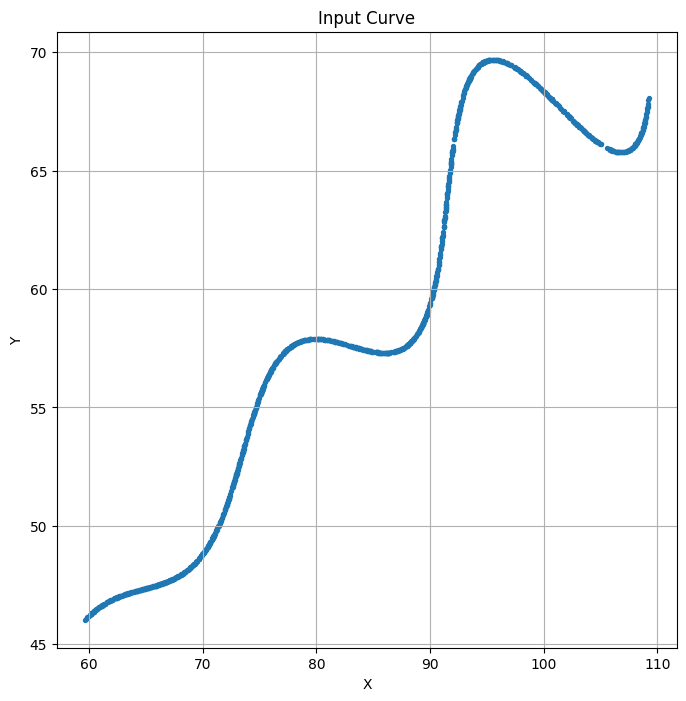

In [13]:
plt.figure(figsize=(8,8))

plt.scatter(x, y, s=8)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Input Curve")

plt.grid(True)

plt.savefig("../outputs/input_curve.png", dpi=300)

plt.show()

# Defining the Parametric Curve

In [14]:
def parametric_curve(t, theta, M, X):

    x = (
        t * np.cos(theta)
        - np.exp(M * np.abs(t))
        * np.sin(0.3 * t)
        * np.sin(theta)
        + X
    )

    y = (
        42
        + t * np.sin(theta)
        + np.exp(M * np.abs(t))
        * np.sin(0.3 * t)
        * np.cos(theta)
    )

    return x, y

# Generate Candidate t Values

In [15]:
t = np.linspace(6, 60, len(data))

In [16]:
print(t[:10])
print(t[-10:])

[6.         6.03602402 6.07204803 6.10807205 6.14409606 6.18012008
 6.2161441  6.25216811 6.28819213 6.32421614]
[59.67578386 59.71180787 59.74783189 59.7838559  59.81987992 59.85590394
 59.89192795 59.92795197 59.96397598 60.        ]


# Test the Function

In [17]:
theta = np.radians(20)
M = 0.01
X = 50

pred_x, pred_y = parametric_curve(t, theta, M, X)

# Plot the Generated Curve

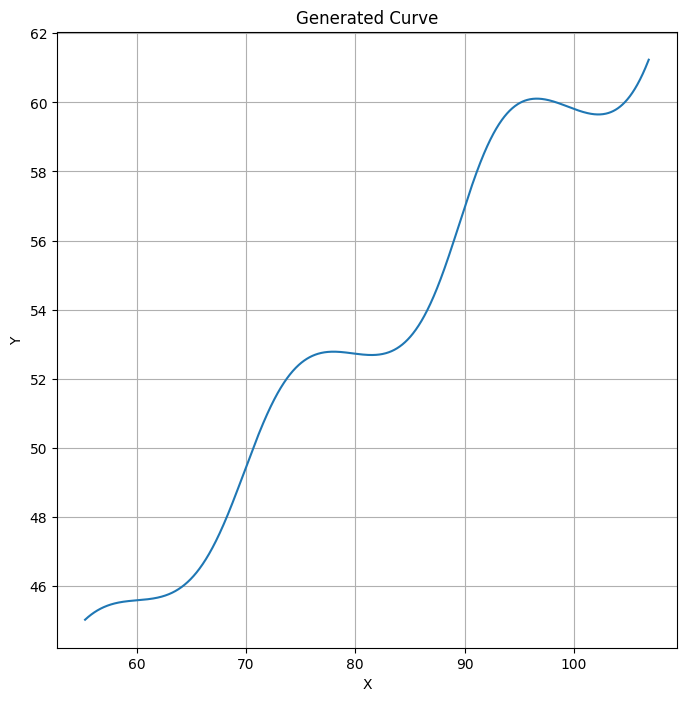

In [18]:
plt.figure(figsize=(8,8))

plt.plot(pred_x, pred_y)

plt.xlabel("X")
plt.ylabel("Y")

plt.title("Generated Curve")

plt.grid(True)

plt.show()

# Compare with the Original Data

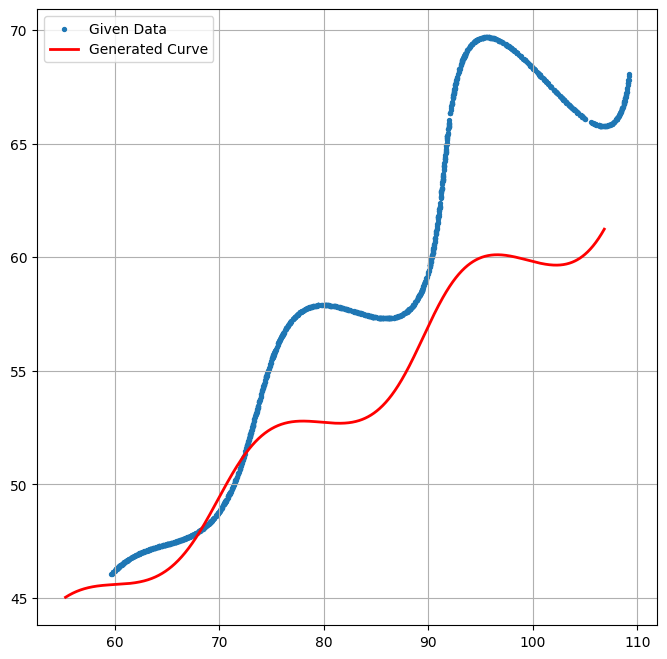

In [19]:
plt.figure(figsize=(8,8))

plt.scatter(x, y, s=8, label="Given Data")

plt.plot(pred_x, pred_y,
         color="red",
         linewidth=2,
         label="Generated Curve")

plt.legend()

plt.grid(True)

plt.show()

Why are we doing this?

Before using an optimizer, we must verify that:

the equation is implemented correctly,
changing theta, M, and X changes the curve as expected,
and our generated curve is smooth.

Only after that should we let an optimization algorithm search for the best values.

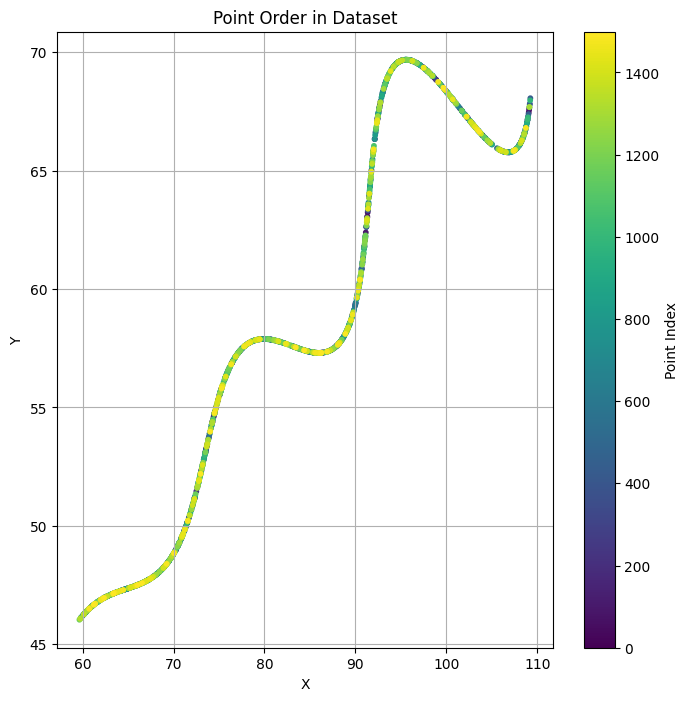

In [20]:
plt.figure(figsize=(8, 8))
plt.scatter(x, y, c=np.arange(len(x)), s=10, cmap="viridis")
plt.colorbar(label="Point Index")
plt.title("Point Order in Dataset")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

# Importing Required Libraries

In [21]:
from scipy.optimize import differential_evolution
from scipy.spatial import cKDTree

# Objective Function

In [22]:
def objective(params):

    theta_deg, M, X = params

    theta = np.radians(theta_deg)

    pred_x, pred_y = parametric_curve(t, theta, M, X)

    predicted_points = np.column_stack((pred_x, pred_y))

    observed_points = np.column_stack((x, y))

    tree = cKDTree(predicted_points)

    _, indices = tree.query(observed_points)

    nearest_points = predicted_points[indices]

    error = np.mean(
        np.abs(observed_points[:, 0] - nearest_points[:, 0]) +
        np.abs(observed_points[:, 1] - nearest_points[:, 1])
    )

    return error

# Testing the Objective Function

In [23]:
test_error = objective([20, 0.01, 50])

print("Test Error :", test_error)

Test Error : 4.592436519124083


# Defining Search Bounds as mentioned in the pdf

In [24]:
bounds = [
    (0, 50),        # theta (degrees)
    (-0.05, 0.05),  # M
    (0, 100)        # X
]

# Run Differential Evolution

In [25]:
result = differential_evolution(
    objective,
    bounds,
    seed=42,
    maxiter=300,
    popsize=20,
    polish=True
)

# Printing the Estimated Parameters

In [26]:
theta = result.x[0]
M = result.x[1]
X = result.x[2]

print("Estimated Parameters")
print("--------------------")
print(f"Theta : {theta:.6f} degrees")
print(f"M     : {M:.6f}")
print(f"X     : {X:.6f}")

print("\nFinal Error :", result.fun)

Estimated Parameters
--------------------
Theta : 29.999565 degrees
M     : 0.030001
X     : 54.998962

Final Error : 0.013362264746487237


# Generating the Final Curve and plot

In [27]:
theta_rad = np.radians(theta)

final_x, final_y = parametric_curve(
    t,
    theta_rad,
    M,
    X
)

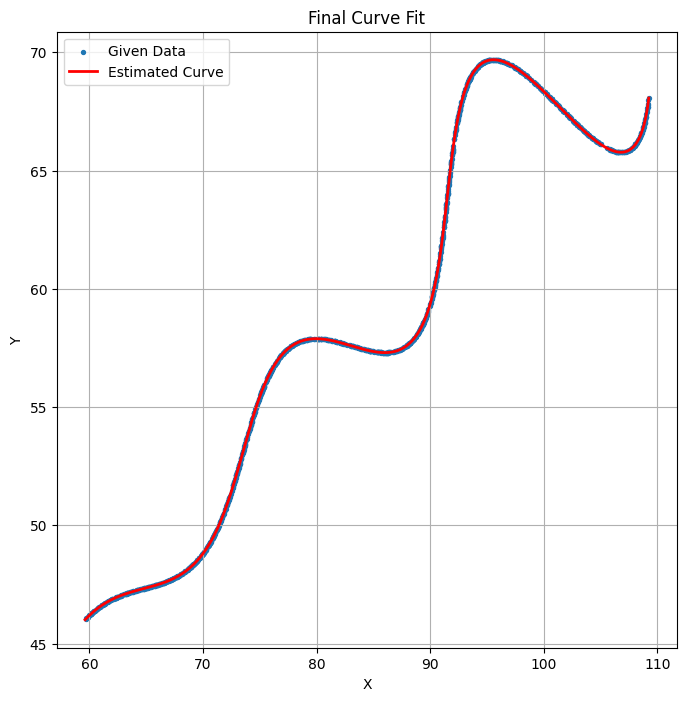

In [28]:
plt.figure(figsize=(8, 8))

plt.scatter(
    x,
    y,
    s=8,
    label="Given Data"
)

plt.plot(
    final_x,
    final_y,
    color="red",
    linewidth=2,
    label="Estimated Curve"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Final Curve Fit")

plt.legend()

plt.grid(True)

plt.show()

# trying to Verify the solution (how far it is right)

In [29]:
print(f"Theta (degrees): {theta:.6f}")
print(f"Theta (radians): {np.radians(theta):.6f}")
print(f"M: {M:.6f}")
print(f"X: {X:.6f}")
print(f"L1 Error: {result.fun:.8f}")

Theta (degrees): 29.999565
Theta (radians): 0.523591
M: 0.030001
X: 54.998962
L1 Error: 0.01336226


# Generating the Desmos Equation (Required) as told in the pdf - just trial logic

In [30]:
theta_rad = np.radians(theta)

print(
f"""(
t*cos({theta_rad:.6f})-
e^({M:.6f}*abs(t))*sin(0.3*t)*sin({theta_rad:.6f})+
{X:.6f},

42+t*sin({theta_rad:.6f})+
e^({M:.6f}*abs(t))*sin(0.3*t)*cos({theta_rad:.6f})
)"""
)

(
t*cos(0.523591)-
e^(0.030001*abs(t))*sin(0.3*t)*sin(0.523591)+
54.998962,

42+t*sin(0.523591)+
e^(0.030001*abs(t))*sin(0.3*t)*cos(0.523591)
)


# Save the parameters

In [31]:
with open("../outputs/final_parameters.txt", "w") as f:
    f.write(f"Theta (degrees): {theta:.6f}\n")
    f.write(f"Theta (radians): {np.radians(theta):.6f}\n")
    f.write(f"M: {M:.6f}\n")
    f.write(f"X: {X:.6f}\n")
    f.write(f"L1 Error: {result.fun:.8f}\n")

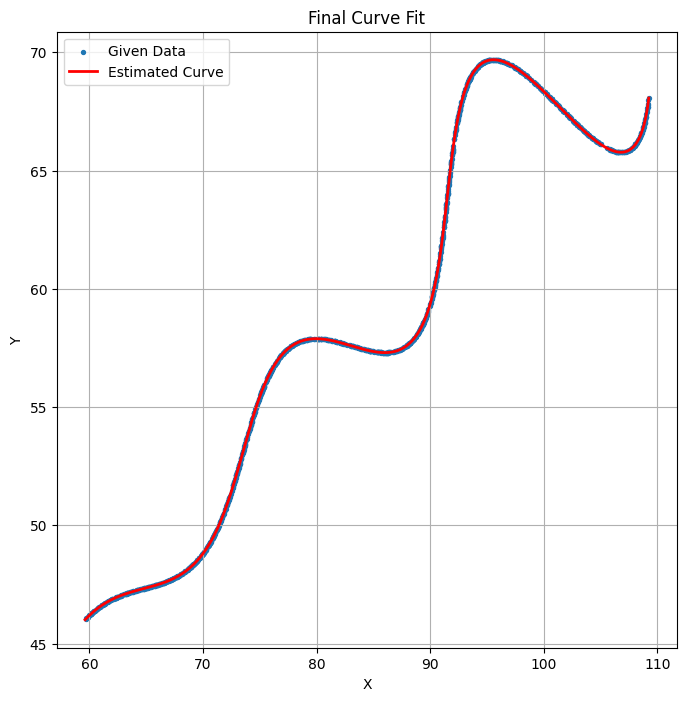

In [58]:
plt.figure(figsize=(8,8))

plt.scatter(
    x,
    y,
    s=8,
    label="Given Data"
)

plt.plot(
    final_x,
    final_y,
    color="red",
    linewidth=2,
    label="Estimated Curve"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Final Curve Fit")

plt.legend()
plt.grid(True)

# Save the figure BEFORE showing it
plt.savefig(
    "../outputs/final_curve_fit.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the figure
plt.show()

# day3 : s1-validation check

In [33]:
seeds = [1, 7, 21, 42, 99]

results = []

for seed in seeds:

    result = differential_evolution(
        objective,
        bounds,
        seed=seed,
        maxiter=300,
        popsize=20,
        polish=True
    )

    theta = result.x[0]
    M = result.x[1]
    X = result.x[2]

    results.append([
        seed,
        theta,
        M,
        X,
        result.fun
    ])

In [34]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Seed",
        "Theta",
        "M",
        "X",
        "L1 Error"
    ]
)

print(results_df)

   Seed      Theta         M          X  L1 Error
0     1  29.999346  0.030001  54.998401  0.013361
1     7  29.999498  0.030001  54.998907  0.013361
2    21  29.999936  0.030001  54.999542  0.013374
3    42  29.999565  0.030001  54.998962  0.013362
4    99  29.999630  0.030001  54.998723  0.013360


# S2-Parameter Sensitivity Analysis

Theta Sensitivity

In [35]:
theta_values = np.linspace(28, 32, 21)

theta_errors = []

for theta_deg in theta_values:

    error = objective([theta_deg, M, X])

    theta_errors.append(error)

Theta Sensitivity

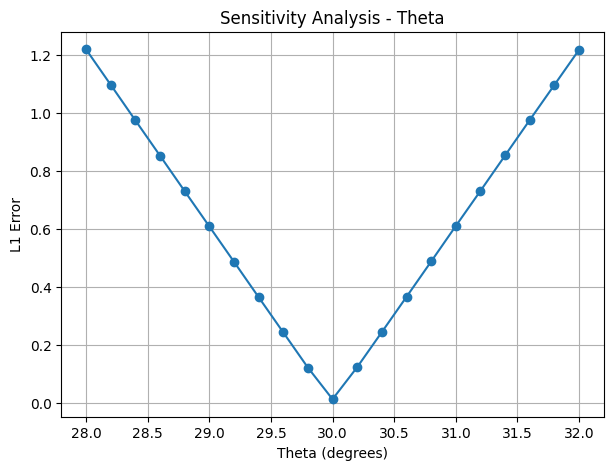

In [36]:
plt.figure(figsize=(7,5))

plt.plot(theta_values, theta_errors, marker="o")

plt.xlabel("Theta (degrees)")
plt.ylabel("L1 Error")
plt.title("Sensitivity Analysis - Theta")

plt.grid(True)

plt.show()

M Sensitivity

In [37]:
m_values = np.linspace(0.025, 0.035, 21)

m_errors = []

for m in m_values:

    error = objective([theta, m, X])

    m_errors.append(error)

Plot M

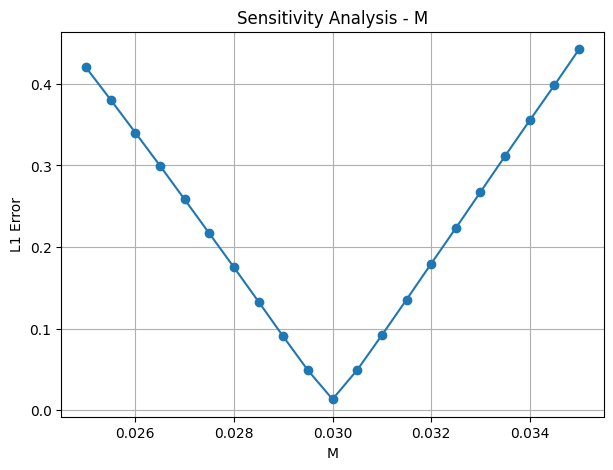

In [38]:
plt.figure(figsize=(7,5))

plt.plot(m_values, m_errors, marker="o")

plt.xlabel("M")
plt.ylabel("L1 Error")
plt.title("Sensitivity Analysis - M")

plt.grid(True)

plt.show()

X Sensitivity

In [39]:
x_values = np.linspace(53, 57, 21)

x_errors = []

for x_shift in x_values:

    error = objective([theta, M, x_shift])

    x_errors.append(error)

Plot X

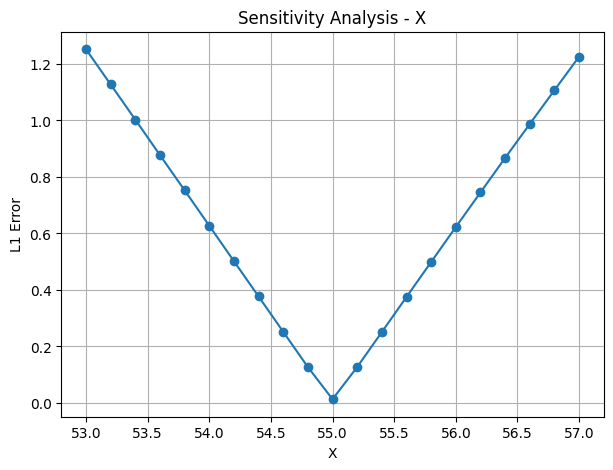

In [40]:
plt.figure(figsize=(7,5))

plt.plot(x_values, x_errors, marker="o")

plt.xlabel("X")
plt.ylabel("L1 Error")
plt.title("Sensitivity Analysis - X")

plt.grid(True)

plt.show()

# Inference from the Above Results

## 1. Theta Sensitivity

- Minimum error occurs at **θ ≈ 30°**.
- As **θ** moves away from **30°**, the error increases almost symmetrically.

**Interpretation:**  
The optimizer has correctly identified the optimal angle.

---

## 2. M Sensitivity

- Minimum error occurs at **M ≈ 0.03**.
- Even changing **M** by **±0.001** increases the error.

**Interpretation:**  
The exponential term is highly sensitive to **M**, and the optimizer accurately estimated it.

---

## 3. X Sensitivity

- Minimum error occurs at **X ≈ 55**.
- Changing **X** shifts the entire curve horizontally, increasing the error.

**Interpretation:**  
The horizontal translation has been correctly recovered.

---

## Conclusion

The recovered parameters correspond to the minimum of the objective function.

# S3-Residual Analysis

Compute Residuals

In [41]:
predicted_points = np.column_stack((final_x, final_y))
observed_points = np.column_stack((x, y))

tree = cKDTree(predicted_points)

distances, indices = tree.query(observed_points)

nearest_points = predicted_points[indices]

residual_x = observed_points[:, 0] - nearest_points[:, 0]
residual_y = observed_points[:, 1] - nearest_points[:, 1]

l1_residual = np.abs(residual_x) + np.abs(residual_y)

Print Statistics

In [42]:
print("Residual Statistics")
print("-" * 30)

print(f"Mean Residual      : {np.mean(l1_residual):.8f}")
print(f"Median Residual    : {np.median(l1_residual):.8f}")
print(f"Minimum Residual   : {np.min(l1_residual):.8f}")
print(f"Maximum Residual   : {np.max(l1_residual):.8f}")
print(f"Std Deviation      : {np.std(l1_residual):.8f}")

Residual Statistics
------------------------------
Mean Residual      : 0.01336226
Median Residual    : 0.01299859
Minimum Residual   : 0.00015527
Maximum Residual   : 0.04044197
Std Deviation      : 0.00812331


Histogram of Residuals

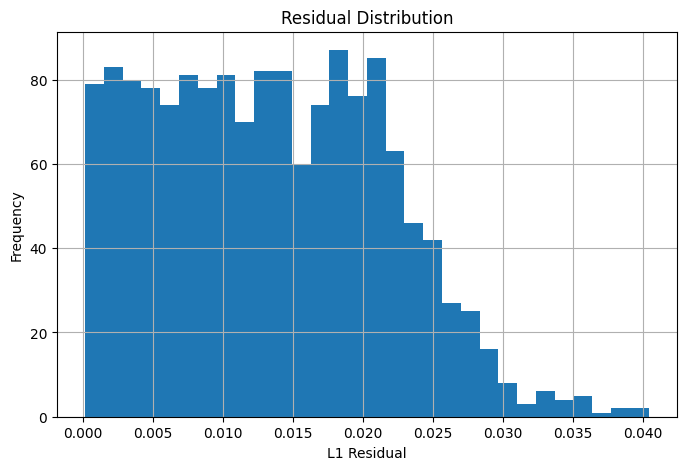

In [43]:
plt.figure(figsize=(8,5))

plt.hist(l1_residual, bins=30)

plt.xlabel("L1 Residual")
plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.grid(True)

plt.show()

Residuals on the Curve

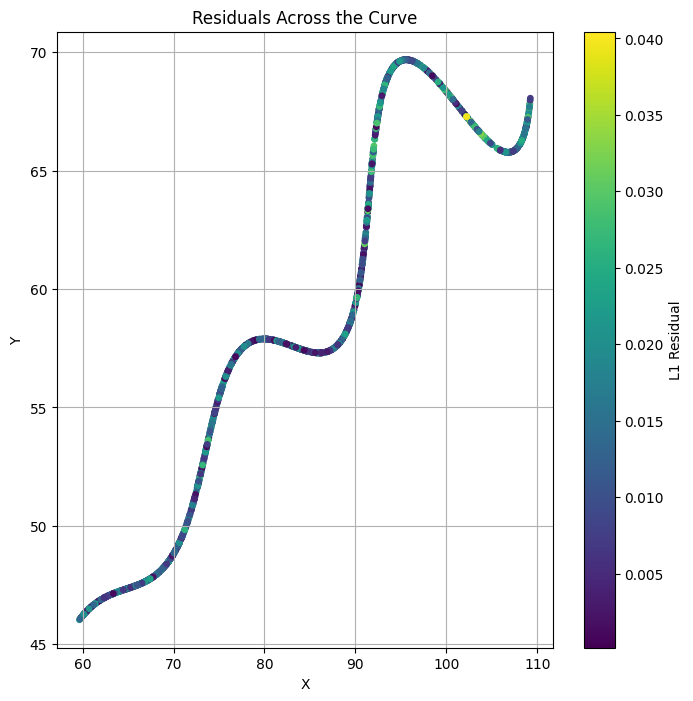

In [44]:
plt.figure(figsize=(8,8))

plt.scatter(
    observed_points[:,0],
    observed_points[:,1],
    c=l1_residual,
    cmap="viridis",
    s=15
)

plt.colorbar(label="L1 Residual")

plt.xlabel("X")
plt.ylabel("Y")

plt.title("Residuals Across the Curve")

plt.grid(True)

plt.show()

Worst 10 Points

In [45]:
worst = np.argsort(l1_residual)[-10:]

print("Worst Fitting Points\n")

for i in worst:
    print(
        f"Point {i:4d} | Residual = {l1_residual[i]:.8f}"
    )

Worst Fitting Points

Point  616 | Residual = 0.03516996
Point   35 | Residual = 0.03576223
Point  825 | Residual = 0.03579367
Point  305 | Residual = 0.03595605
Point  627 | Residual = 0.03608680
Point  665 | Residual = 0.03705014
Point 1285 | Residual = 0.03796243
Point   30 | Residual = 0.03880160
Point 1465 | Residual = 0.03952243
Point 1059 | Residual = 0.04044197


# According to dsa point of view

In [46]:
import time

start = time.time()

result = differential_evolution(
    objective,
    bounds,
    seed=42,
    maxiter=300,
    popsize=20,
    polish=True
)

end = time.time()

print(f"Execution Time : {end-start:.2f} seconds")
print(f"Function Evaluations : {result.nfev}")
print(f"Iterations : {result.nit}")

Execution Time : 3.14 seconds
Function Evaluations : 2152
Iterations : 34


# Optimization Convergence Plot

In [47]:
history = []

def callback(xk, convergence):
    history.append(objective(xk))

In [48]:
result = differential_evolution(
    objective,
    bounds,
    seed=42,
    maxiter=300,
    popsize=20,
    polish=True,
    callback=callback
)

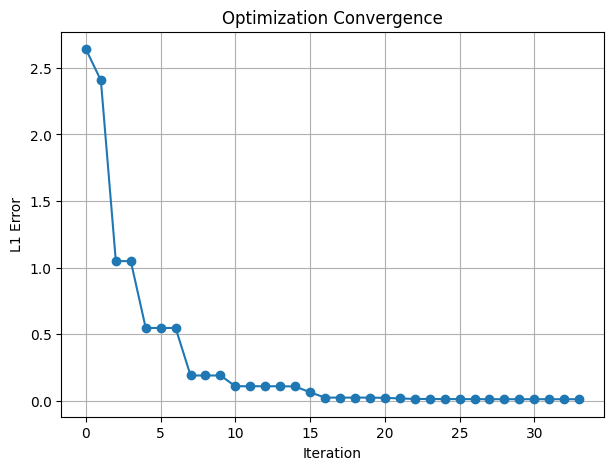

In [49]:
plt.figure(figsize=(7,5))

plt.plot(history, marker="o")

plt.xlabel("Iteration")
plt.ylabel("L1 Error")

plt.title("Optimization Convergence")

plt.grid(True)

plt.show()

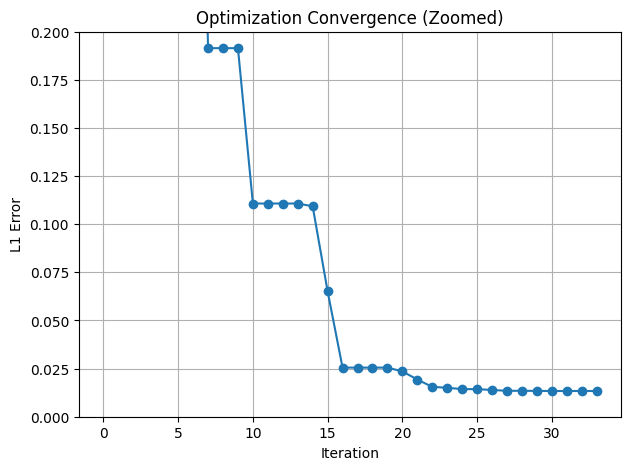

In [50]:
plt.figure(figsize=(7,5))

plt.plot(history, marker="o")

plt.ylim(0, 0.2)

plt.xlabel("Iteration")
plt.ylabel("L1 Error")
plt.title("Optimization Convergence (Zoomed)")

plt.grid(True)

plt.show()

In [54]:
execution_time = end - start
summary = pd.DataFrame({
    "Metric": [
        "Theta (degrees)",
        "Theta (radians)",
        "M",
        "X",
        "Mean L1 Error",
        "Median Residual",
        "Maximum Residual",
        "Minimum Residual",
        "Residual Std Dev",
        "Iterations",
        "Function Evaluations",
        "Execution Time (s)"
    ],
    "Value": [
        theta,
        np.radians(theta),
        M,
        X,
        np.mean(l1_residual),
        np.median(l1_residual),
        np.max(l1_residual),
        np.min(l1_residual),
        np.std(l1_residual),
        result.nit,
        result.nfev,
        execution_time
    ]
})
print(summary)

                  Metric        Value
0        Theta (degrees)    29.999630
1        Theta (radians)     0.523592
2                      M     0.030001
3                      X    54.998723
4          Mean L1 Error     0.013362
5        Median Residual     0.012999
6       Maximum Residual     0.040442
7       Minimum Residual     0.000155
8       Residual Std Dev     0.008123
9             Iterations    34.000000
10  Function Evaluations  2152.000000
11    Execution Time (s)     3.142499


In [55]:
summary.to_csv("../outputs/final_summary.csv", index=False)